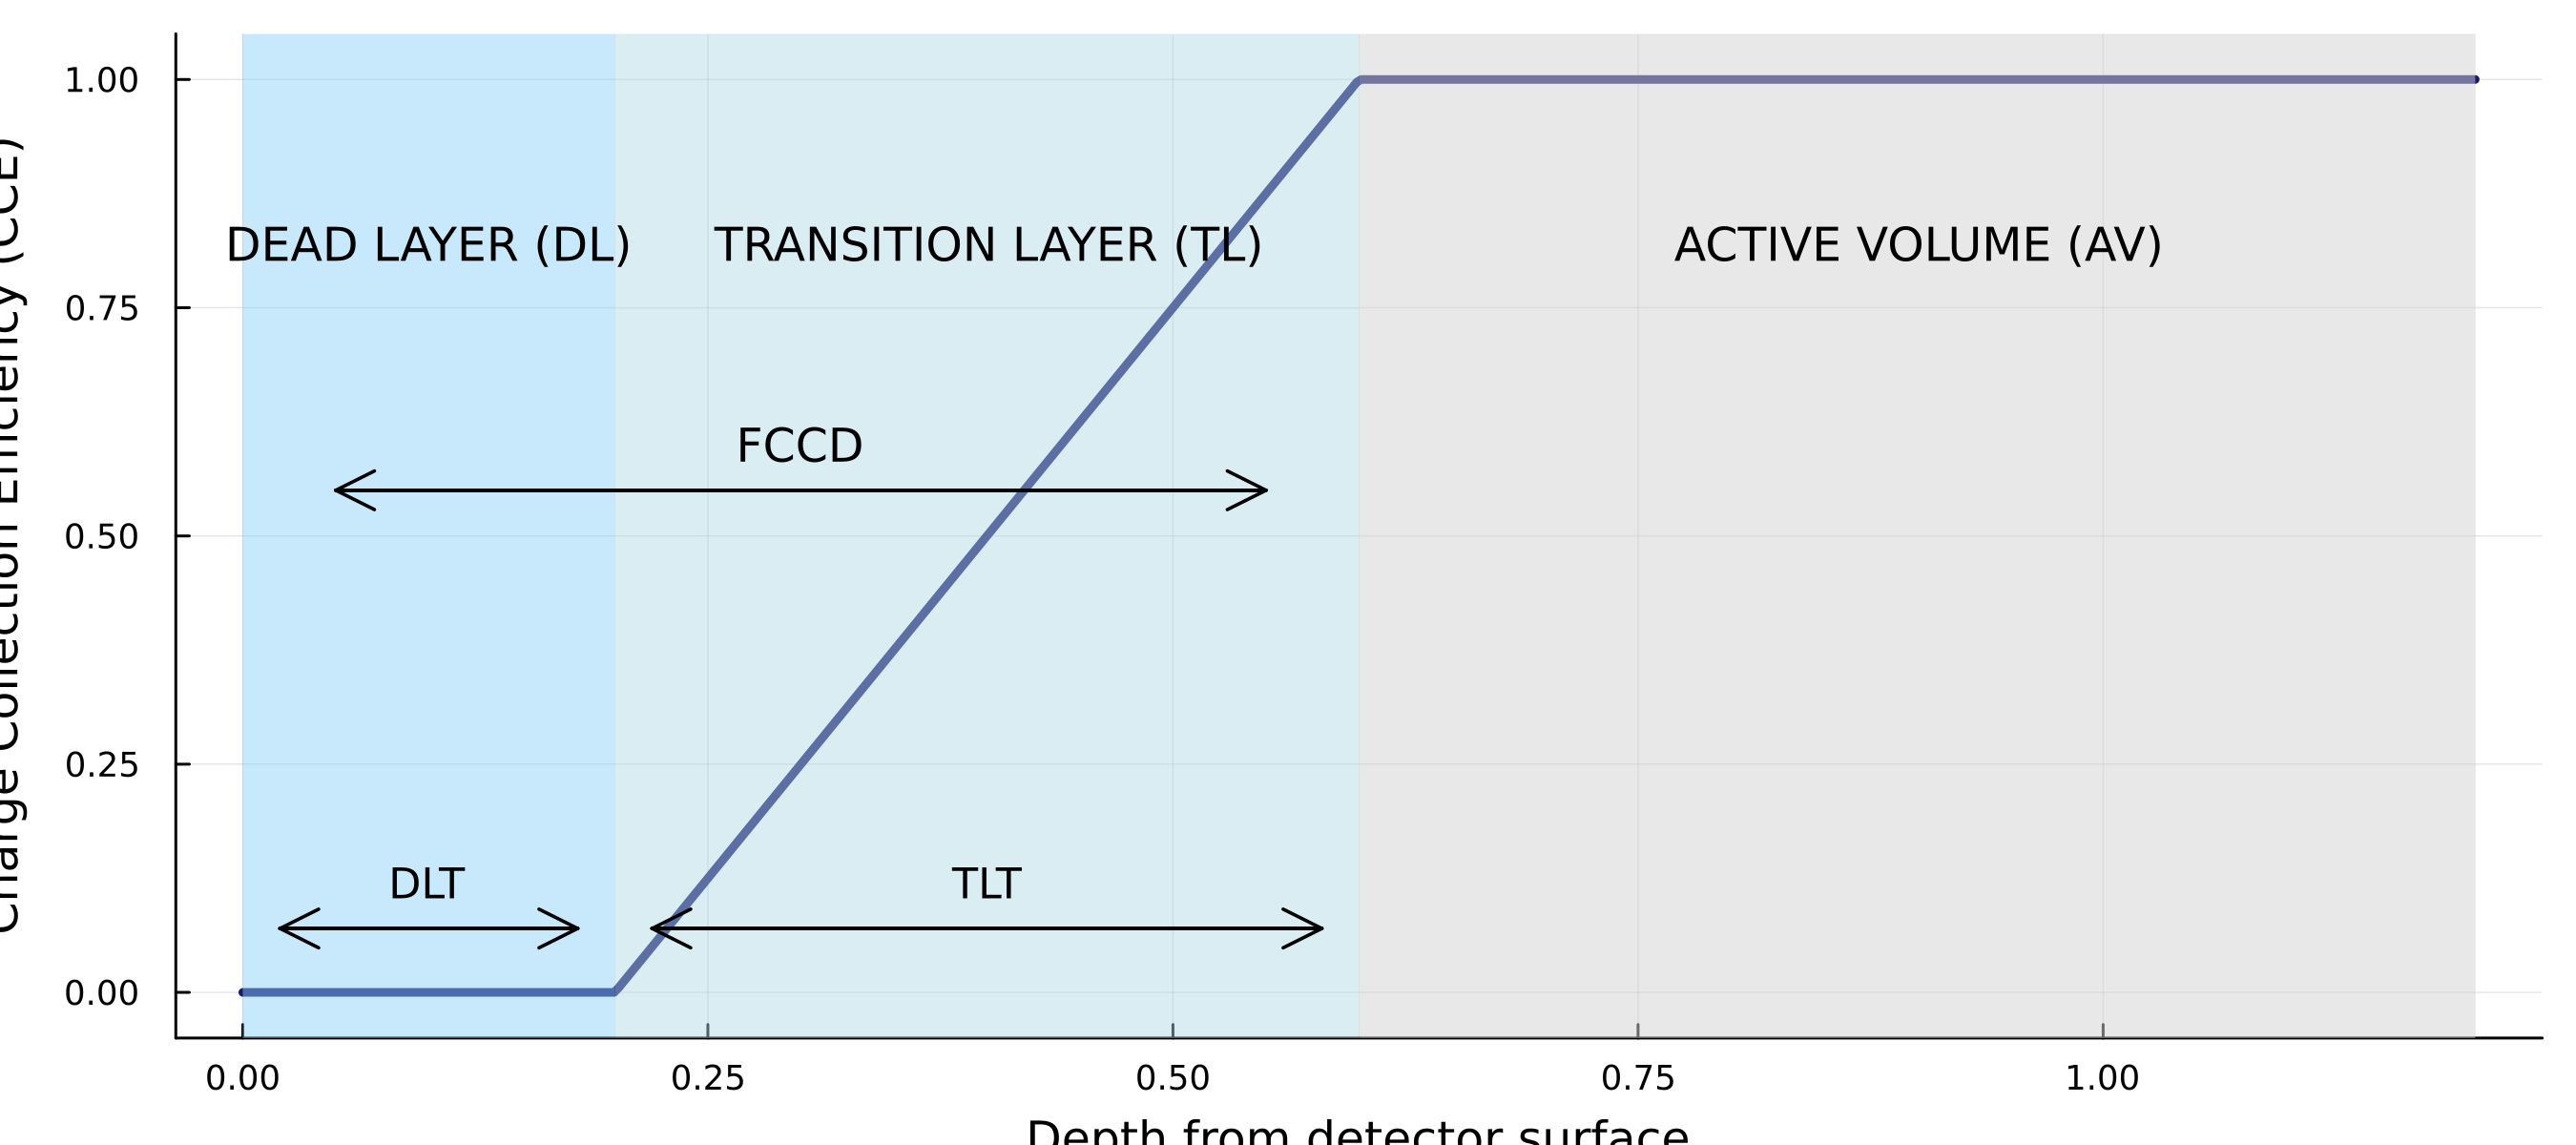

In [7]:
using Plots
gr(size=(900,400), dpi=300)

# -------------------------
# Profondità (mm)
# -------------------------
DLT = 0.2
TLT = 0.4
AV_start = DLT + TLT
xmax = 1.2

# -------------------------
# Funzione CCE
# -------------------------
function CCE(x)
    if x < DLT
        return 0.0
    elseif x < AV_start
        return (x - DLT) / TLT
    else
        return 1.0
    end
end

x = range(0, xmax, length=500)
y = CCE.(x)

# -------------------------
# Plot base (FIX margini)
# -------------------------
p = plot(
    x, y,
    linewidth=3,
    color=:midnightblue,
    xlabel="Depth from detector surface",
    ylabel="Charge Collection Efficiency (CCE)",
    ylim=(-0.05, 1.05),
    legend=false
)

# -------------------------
# Aree pastello
# -------------------------
vspan!([0, DLT], color=:lightskyblue, alpha=0.45)
vspan!([DLT, AV_start], color=:lightblue, alpha=0.45)
vspan!([AV_start, xmax], color=:lightgray, alpha=0.5)

# -------------------------
# Testi regioni
# -------------------------
annotate!(DLT/2, 0.82, text("DEAD LAYER (DL)", 11, :black, :center))
annotate!(DLT + TLT/2, 0.82, text("TRANSITION LAYER (TL)", 11, :black, :center))
annotate!(AV_start + (xmax-AV_start)/2, 0.82, text("ACTIVE VOLUME (AV)", 11, :black, :center))

# -------------------------
# Frecce doppia punta (più sottili)
# -------------------------
lw_arrow = 1.2
y_arrow1 = 0.07
y_arrow2 = 0.55

# Dead Layer Thickness
annotate!(DLT/2, y_arrow1 + 0.05, text("DLT", 10))
quiver!(
    [0.02, DLT-0.02], [y_arrow1, y_arrow1],
    quiver=([DLT-0.04, -(DLT-0.04)], [0.0, 0.0]),
    arrow=true, lw=lw_arrow, color=:black
)

# Transition Layer Thickness
annotate!(DLT + TLT/2, y_arrow1 + 0.05, text("TLT", 10))
quiver!(
    [DLT+0.02, AV_start-0.02], [y_arrow1, y_arrow1],
    quiver=([TLT-0.04, -(TLT-0.04)], [0.0, 0.0]),
    arrow=true, lw=lw_arrow, color=:black
)

# Full Charge Collection Depth
annotate!(AV_start/2, y_arrow2 + 0.05, text("FCCD", 11))
quiver!(
    [0.05, AV_start-0.05], [y_arrow2, y_arrow2],
    quiver=([AV_start-0.1, -(AV_start-0.1)], [0.0, 0.0]),
    arrow=true, lw=lw_arrow, color=:black
)

display(p)
